In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot  as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
bureau=pd.read_csv('bureau_data.csv')
customers=pd.read_csv('customers.csv')
loans=pd.read_csv('loans.csv')

In [46]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [3]:
bureau

,cust_id,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,C00001,1,1,42,0,0,3,7
1,C00002,3,1,96,12,60,5,4
2,C00003,2,1,82,24,147,6,58
3,C00004,3,0,115,15,87,5,26
4,C00005,4,2,120,0,0,5,10
...,...,...,...,...,...,...,...,...
49995,C49996,4,2,165,1,6,8,24
49996,C49997,4,0,161,0,0,4,91
49997,C49998,4,1,42,0,0,7,38
49998,C49999,1,2,42,9,47,4,17


In [4]:
customers.head()

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,Delhi,110001
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,Tamil Nadu,600001
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,West Bengal,700001
3,C00004,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,Karnataka,560001
4,C00005,37,M,Married,Salaried,3432000,3,Owned,28,Pune,Maharashtra,411001


In [5]:
loans.head()

,loan_id,cust_id,loan_purpose,loan_type,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
0,L00001,C00001,Auto,Secured,3004000,2467000,49340.0,444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,False
1,L00002,C00002,Home,Secured,4161000,3883000,77660.0,698940,3106400,30,709309,464100,2019-07-24,2019-08-15,False
2,L00003,C00003,Personal,Unsecured,2401000,2170000,43400.0,390600,1736000,21,1562399,1476042,2019-07-24,2019-08-21,False
3,L00004,C00004,Personal,Unsecured,2345000,1747000,34940.0,314460,1397600,6,1257839,1031094,2019-07-24,2019-08-09,False
4,L00005,C00005,Auto,Secured,4647000,4520000,90400.0,813600,3616000,28,1772334,1032458,2019-07-24,2019-08-02,False


In [6]:
bureau.shape

(50000, 8)

In [7]:
customers.shape

(50000, 12)

In [8]:
loans.shape

(50000, 15)

In [9]:
bureau.describe()

,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
count,50000.000000,50000.00000,50000.000000,50000.00000,50000.000000,50000.000000,50000.00000
mean,2.500140,1.00106,76.127140,4.87890,26.858000,5.009340,43.36142
std,1.118725,0.81412,43.762469,5.85032,32.832832,2.029122,29.35598
min,1.000000,0.00000,1.000000,0.00000,0.000000,1.000000,0.00000
25%,1.000000,0.00000,42.000000,0.00000,0.000000,4.000000,18.00000
50%,3.000000,1.00000,71.000000,3.00000,14.000000,5.000000,39.00000
75%,4.000000,2.00000,107.000000,9.00000,46.000000,6.000000,67.00000
max,4.000000,2.00000,223.000000,24.00000,171.000000,9.000000,99.00000


In [10]:
customers.describe()

,age,income,number_of_dependants,years_at_current_address,zipcode
count,50000.000000,5.000000e+04,50000.000000,50000.000000,50000.000000
mean,39.550980,2.640898e+06,1.939540,16.018440,419090.860000
std,9.847752,2.629441e+06,1.535517,8.926489,168982.674047
min,18.000000,0.000000e+00,0.000000,1.000000,110001.000000
25%,33.000000,8.030000e+05,0.000000,8.000000,302001.000000
50%,40.000000,1.892000e+06,2.000000,16.000000,400001.000000
75%,46.000000,3.332250e+06,3.000000,24.000000,560001.000000
max,70.000000,1.199900e+07,5.000000,31.000000,700001.000000


In [11]:
loans.describe()

,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application
count,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,50000.000000,5.000000e+04,5.000000e+04
mean,4.704828e+06,3.999679e+06,8.049471e+04,7.199422e+05,3.199743e+06,25.940520,1.337636e+06,9.891264e+05
std,6.267276e+06,5.376552e+06,1.173123e+05,9.677794e+05,4.301242e+06,12.433163,1.214714e+06,1.046072e+06
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.000000,-1.000000e+00,0.000000e+00
25%,1.147000e+06,9.670000e+05,1.934000e+04,1.740600e+05,7.736000e+05,16.000000,4.247990e+05,2.870075e+05
50%,2.656000e+06,2.240000e+06,4.480000e+04,4.032000e+05,1.792000e+06,24.000000,1.002309e+06,6.685250e+05
75%,5.172250e+06,4.611000e+06,9.224000e+04,8.299800e+05,3.688800e+06,35.000000,1.790751e+06,1.238667e+06
max,5.217500e+07,4.781900e+07,5.698030e+06,8.607420e+06,3.825520e+07,59.000000,5.000000e+06,7.846643e+06


In [12]:
bureau.isnull().sum()

cust_id                      0
number_of_open_accounts      0
number_of_closed_accounts    0
total_loan_months            0
delinquent_months            0
total_dpd                    0
enquiry_count                0
credit_utilization_ratio     0
dtype: int64

In [13]:
customers.isnull().sum()

cust_id                      0
age                          0
gender                       0
marital_status               0
employment_status            0
income                       0
number_of_dependants         0
residence_type              62
years_at_current_address     0
city                         0
state                        0
zipcode                      0
dtype: int64

### customers-> residence type contains some null value

In [14]:
loans.isnull().sum()

loan_id                        0
cust_id                        0
loan_purpose                   0
loan_type                      0
sanction_amount                0
loan_amount                    0
processing_fee                 0
gst                            0
net_disbursement               0
loan_tenure_months             0
principal_outstanding          0
bank_balance_at_application    0
disbursal_date                 0
installment_start_dt           0
default                        0
dtype: int64

In [15]:
bureau.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   cust_id                    50000 non-null  object
 1   number_of_open_accounts    50000 non-null  int64 
 2   number_of_closed_accounts  50000 non-null  int64 
 3   total_loan_months          50000 non-null  int64 
 4   delinquent_months          50000 non-null  int64 
 5   total_dpd                  50000 non-null  int64 
 6   enquiry_count              50000 non-null  int64 
 7   credit_utilization_ratio   50000 non-null  int64 
dtypes: int64(7), object(1)
memory usage: 3.1+ MB


In [16]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   cust_id                   50000 non-null  object
 1   age                       50000 non-null  int64 
 2   gender                    50000 non-null  object
 3   marital_status            50000 non-null  object
 4   employment_status         50000 non-null  object
 5   income                    50000 non-null  int64 
 6   number_of_dependants      50000 non-null  int64 
 7   residence_type            49938 non-null  object
 8   years_at_current_address  50000 non-null  int64 
 9   city                      50000 non-null  object
 10  state                     50000 non-null  object
 11  zipcode                   50000 non-null  int64 
dtypes: int64(5), object(7)
memory usage: 4.6+ MB


In [17]:
loans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   loan_id                      50000 non-null  object 
 1   cust_id                      50000 non-null  object 
 2   loan_purpose                 50000 non-null  object 
 3   loan_type                    50000 non-null  object 
 4   sanction_amount              50000 non-null  int64  
 5   loan_amount                  50000 non-null  int64  
 6   processing_fee               50000 non-null  float64
 7   gst                          50000 non-null  int64  
 8   net_disbursement             50000 non-null  int64  
 9   loan_tenure_months           50000 non-null  int64  
 10  principal_outstanding        50000 non-null  int64  
 11  bank_balance_at_application  50000 non-null  int64  
 12  disbursal_date               50000 non-null  object 
 13  installment_star

In [18]:
bureau_df = bureau.select_dtypes(include=['number']).columns.tolist()
bureau_df

['number_of_open_accounts',
 'number_of_closed_accounts',
 'total_loan_months',
 'delinquent_months',
 'total_dpd',
 'enquiry_count',
 'credit_utilization_ratio']

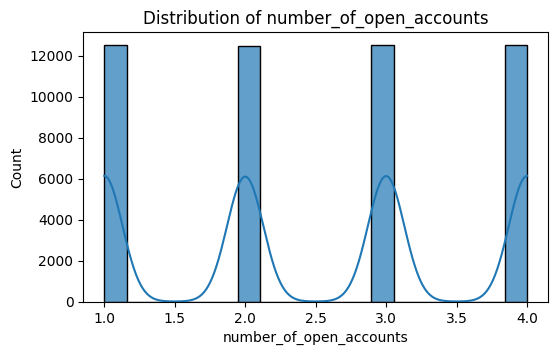

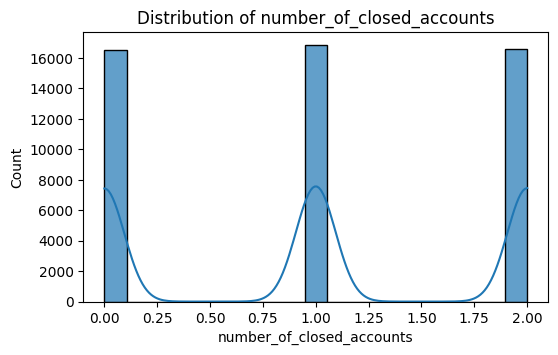

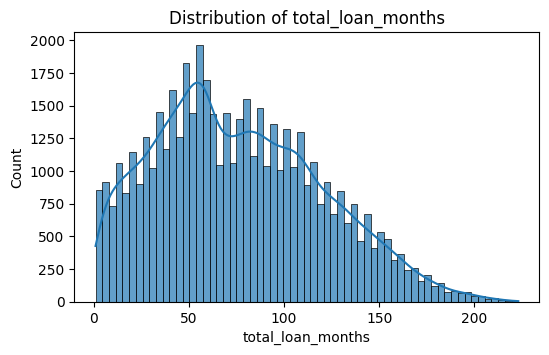

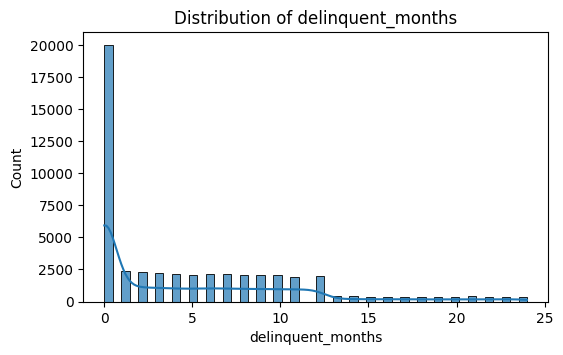

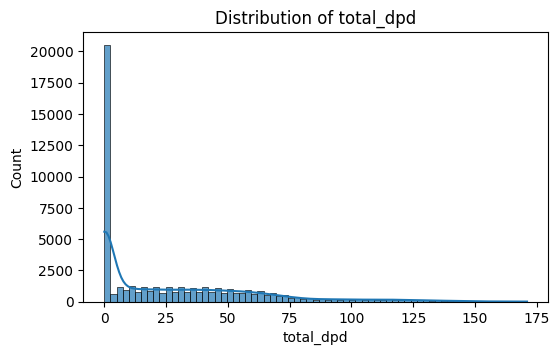

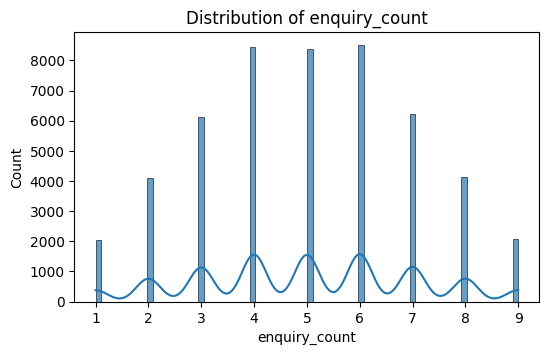

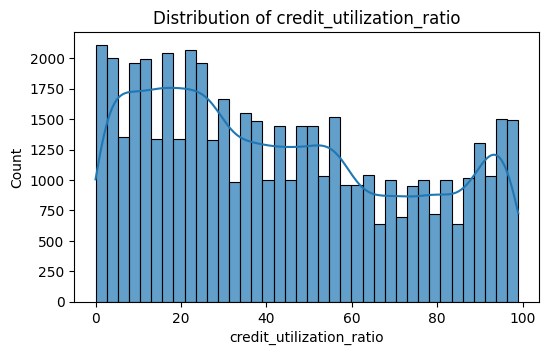

In [19]:
for cols in bureau_df:
    plt.figure(figsize=(6, 3.5))
    sns.histplot(bureau[cols], edgecolor='black', alpha=0.7,kde=True)
    plt.title(f'Distribution of {cols}')
    plt.xlabel(cols)
    plt.ylabel('Count')
    plt.show()

<Axes: xlabel='number_of_open_accounts', ylabel='count'>

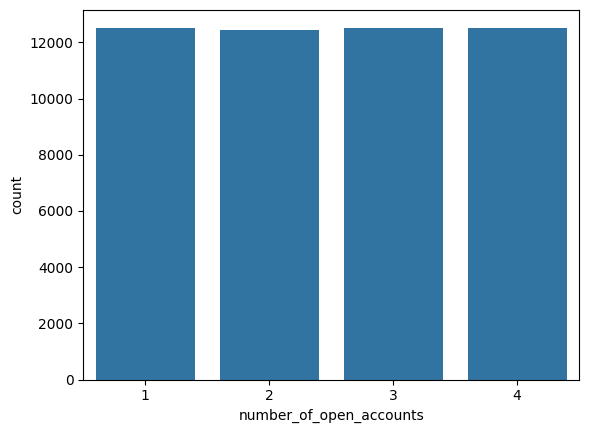

In [20]:
sns.countplot(x=bureau['number_of_open_accounts'])

### Findings outliers

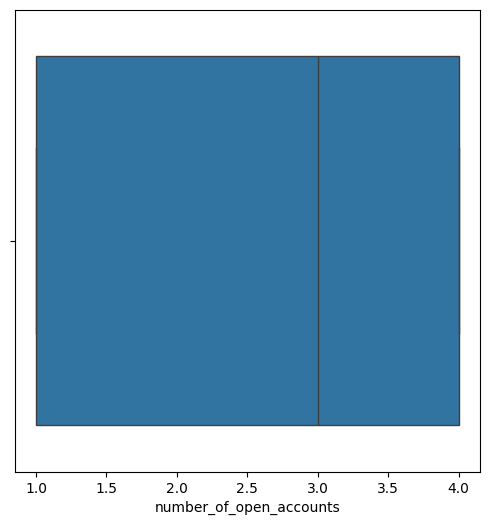

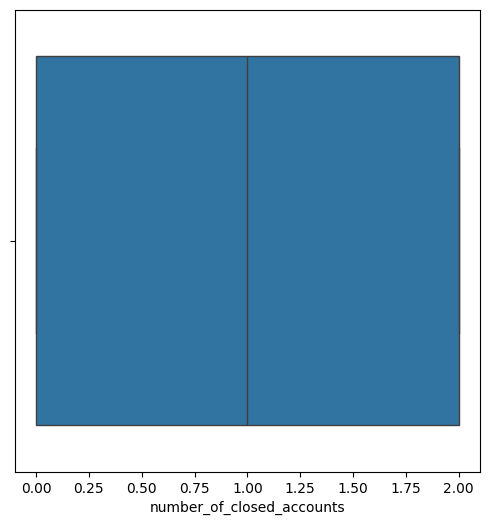

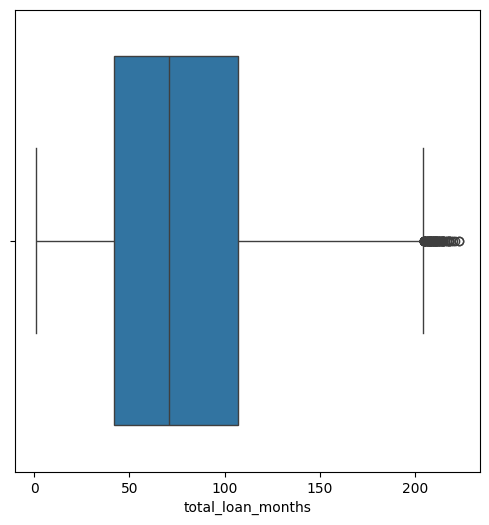

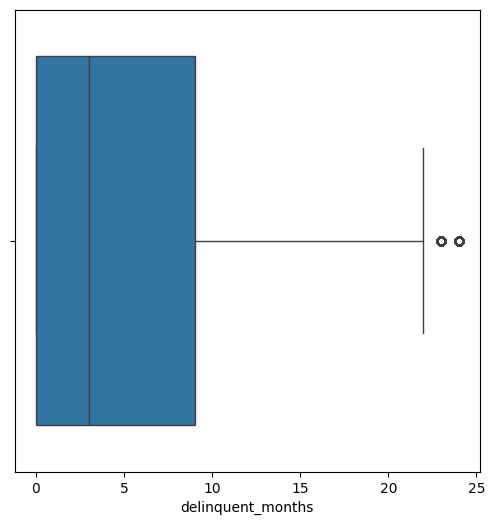

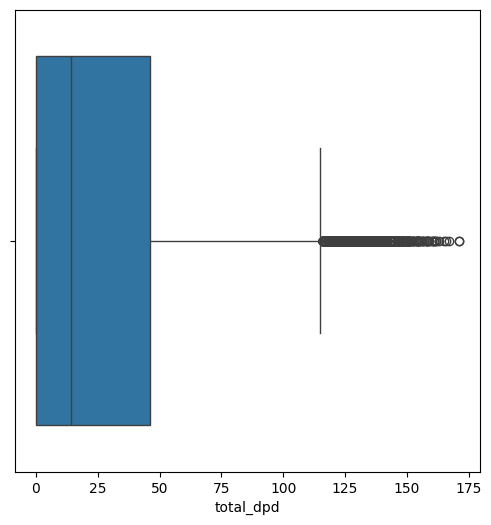

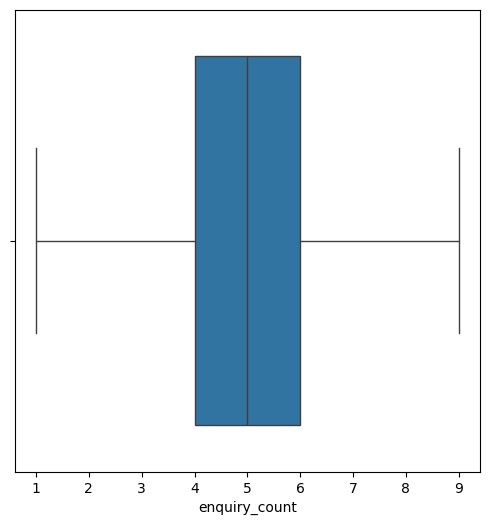

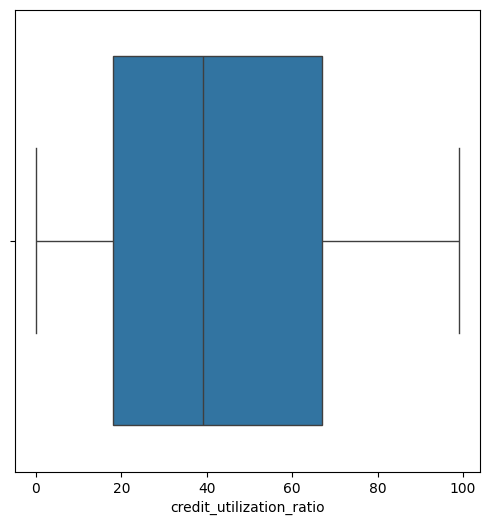

In [21]:
for cols in bureau_df:
    plt.figure(figsize=(6,6))
    sns.boxplot(x=bureau[cols])

### Total_loans_months and delinquent_monts contains outliers

### Finding Correlations

<Axes: >

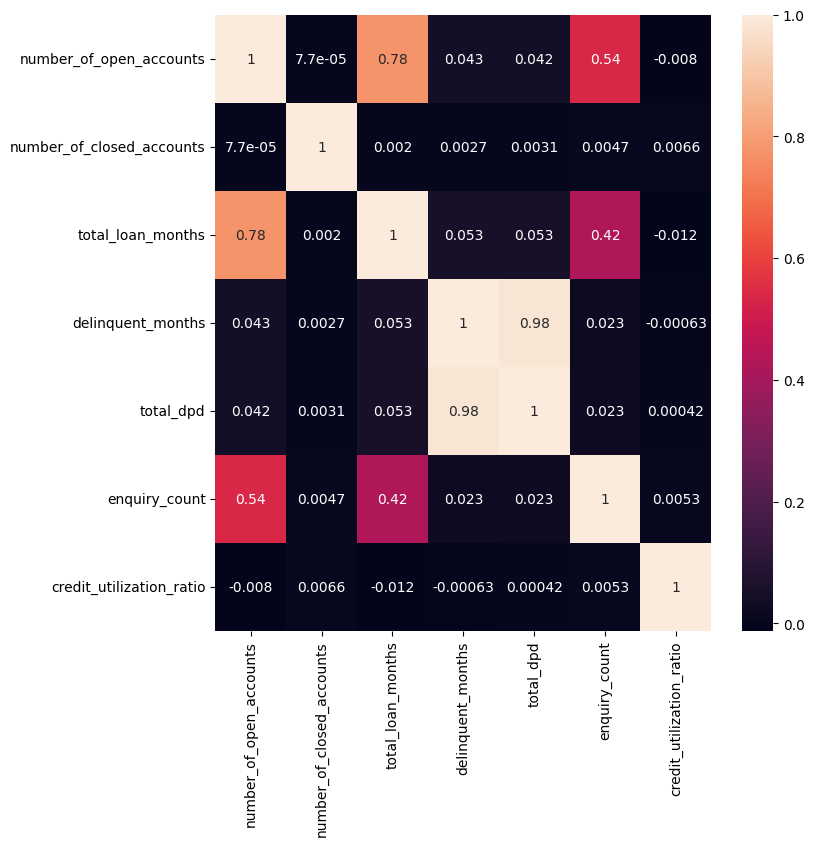

In [22]:
plt.figure(figsize=(8,8))
sns.heatmap(bureau.corr(numeric_only=True),annot=True)

### Data Cleaning

In [23]:
bureau_cleaned=bureau.copy()
bureau_cleaned.head()

,cust_id,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,C00001,1,1,42,0,0,3,7
1,C00002,3,1,96,12,60,5,4
2,C00003,2,1,82,24,147,6,58
3,C00004,3,0,115,15,87,5,26
4,C00005,4,2,120,0,0,5,10


In [24]:
bureau_cleaned.duplicated().sum()

np.int64(0)

In [25]:
bureau_cleaned.isnull().sum()

cust_id                      0
number_of_open_accounts      0
number_of_closed_accounts    0
total_loan_months            0
delinquent_months            0
total_dpd                    0
enquiry_count                0
credit_utilization_ratio     0
dtype: int64

In [26]:
bureau_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   cust_id                    50000 non-null  object
 1   number_of_open_accounts    50000 non-null  int64 
 2   number_of_closed_accounts  50000 non-null  int64 
 3   total_loan_months          50000 non-null  int64 
 4   delinquent_months          50000 non-null  int64 
 5   total_dpd                  50000 non-null  int64 
 6   enquiry_count              50000 non-null  int64 
 7   credit_utilization_ratio   50000 non-null  int64 
dtypes: int64(7), object(1)
memory usage: 3.1+ MB


### loans

In [27]:
loans.head()

,loan_id,cust_id,loan_purpose,loan_type,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
0,L00001,C00001,Auto,Secured,3004000,2467000,49340.0,444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,False
1,L00002,C00002,Home,Secured,4161000,3883000,77660.0,698940,3106400,30,709309,464100,2019-07-24,2019-08-15,False
2,L00003,C00003,Personal,Unsecured,2401000,2170000,43400.0,390600,1736000,21,1562399,1476042,2019-07-24,2019-08-21,False
3,L00004,C00004,Personal,Unsecured,2345000,1747000,34940.0,314460,1397600,6,1257839,1031094,2019-07-24,2019-08-09,False
4,L00005,C00005,Auto,Secured,4647000,4520000,90400.0,813600,3616000,28,1772334,1032458,2019-07-24,2019-08-02,False


In [28]:
loans['default']=loans['default'].astype(int)
loans

,loan_id,cust_id,loan_purpose,loan_type,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
0,L00001,C00001,Auto,Secured,3004000,2467000,49340.0,444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,0
1,L00002,C00002,Home,Secured,4161000,3883000,77660.0,698940,3106400,30,709309,464100,2019-07-24,2019-08-15,0
2,L00003,C00003,Personal,Unsecured,2401000,2170000,43400.0,390600,1736000,21,1562399,1476042,2019-07-24,2019-08-21,0
3,L00004,C00004,Personal,Unsecured,2345000,1747000,34940.0,314460,1397600,6,1257839,1031094,2019-07-24,2019-08-09,0
4,L00005,C00005,Auto,Secured,4647000,4520000,90400.0,813600,3616000,28,1772334,1032458,2019-07-24,2019-08-02,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,L49996,C49996,Personal,Unsecured,610000,535000,10700.0,96300,428000,22,385199,178470,2024-07-22,2024-08-15,0
49996,L49997,C49997,Auto,Secured,4211000,3243000,64860.0,583740,2594400,15,1656484,1040735,2024-07-22,2024-07-29,0
49997,L49998,C49998,Home,Secured,4097000,3740000,74800.0,673200,2992000,37,912691,355461,2024-07-22,2024-07-25,0
49998,L49999,C49999,Home,Secured,1871000,1630000,32600.0,293400,1304000,37,300035,179453,2024-07-22,2024-07-29,0


In [29]:
loans['default'].value_counts()

default
0    45703
1     4297
Name: count, dtype: int64

## merging the dataframe 

In [30]:
df=pd.merge(bureau,customers,on='cust_id')
df

,cust_id,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode
0,C00001,1,1,42,0,0,3,7,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,Delhi,110001
1,C00002,3,1,96,12,60,5,4,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,Tamil Nadu,600001
2,C00003,2,1,82,24,147,6,58,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,West Bengal,700001
3,C00004,3,0,115,15,87,5,26,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,Karnataka,560001
4,C00005,4,2,120,0,0,5,10,37,M,Married,Salaried,3432000,3,Owned,28,Pune,Maharashtra,411001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,C49996,4,2,165,1,6,8,24,40,F,Single,Salaried,775000,2,Owned,11,Chennai,Tamil Nadu,600001
49996,C49997,4,0,161,0,0,4,91,39,M,Single,Salaried,3117000,0,Owned,9,Kolkata,West Bengal,700001
49997,C49998,4,1,42,0,0,7,38,45,F,Single,Self-Employed,1329000,0,Rented,27,Bangalore,Karnataka,560001
49998,C49999,1,2,42,9,47,4,17,42,F,Single,Self-Employed,533000,2,Mortgage,20,Hyderabad,Telangana,500001


In [31]:
df=pd.merge(df,loans,on='cust_id')
df

,cust_id,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,age,gender,...,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
0,C00001,1,1,42,0,0,3,7,44,M,...,2467000,49340.0,444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,0
1,C00002,3,1,96,12,60,5,4,38,M,...,3883000,77660.0,698940,3106400,30,709309,464100,2019-07-24,2019-08-15,0
2,C00003,2,1,82,24,147,6,58,46,F,...,2170000,43400.0,390600,1736000,21,1562399,1476042,2019-07-24,2019-08-21,0
3,C00004,3,0,115,15,87,5,26,55,F,...,1747000,34940.0,314460,1397600,6,1257839,1031094,2019-07-24,2019-08-09,0
4,C00005,4,2,120,0,0,5,10,37,M,...,4520000,90400.0,813600,3616000,28,1772334,1032458,2019-07-24,2019-08-02,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,C49996,4,2,165,1,6,8,24,40,F,...,535000,10700.0,96300,428000,22,385199,178470,2024-07-22,2024-08-15,0
49996,C49997,4,0,161,0,0,4,91,39,M,...,3243000,64860.0,583740,2594400,15,1656484,1040735,2024-07-22,2024-07-29,0
49997,C49998,4,1,42,0,0,7,38,45,F,...,3740000,74800.0,673200,2992000,37,912691,355461,2024-07-22,2024-07-25,0
49998,C49999,1,2,42,9,47,4,17,42,F,...,1630000,32600.0,293400,1304000,37,300035,179453,2024-07-22,2024-07-29,0


In [32]:
df.columns

Index(['cust_id', 'number_of_open_accounts', 'number_of_closed_accounts',
       'total_loan_months', 'delinquent_months', 'total_dpd', 'enquiry_count',
       'credit_utilization_ratio', 'age', 'gender', 'marital_status',
       'employment_status', 'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode', 'loan_id',
       'loan_purpose', 'loan_type', 'sanction_amount', 'loan_amount',
       'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application',
       'disbursal_date', 'installment_start_dt', 'default'],
      dtype='object')

In [55]:
X=df.drop('default',axis=1)
y=df['default']
df_train,df_test,y_train,y_test=train_test_split(X,y,test_size=0.25,stratify=y, random_state=42)
df_train.shape,df_test.shape

((37500, 32), (12500, 32))

In [34]:
df_train.isna().sum()

cust_id                         0
number_of_open_accounts         0
number_of_closed_accounts       0
total_loan_months               0
delinquent_months               0
total_dpd                       0
enquiry_count                   0
credit_utilization_ratio        0
age                             0
gender                          0
marital_status                  0
employment_status               0
income                          0
number_of_dependants            0
residence_type                 47
years_at_current_address        0
city                            0
state                           0
zipcode                         0
loan_id                         0
loan_purpose                    0
loan_type                       0
sanction_amount                 0
loan_amount                     0
processing_fee                  0
gst                             0
net_disbursement                0
loan_tenure_months              0
principal_outstanding           0
bank_balance_a

In [35]:
residence=df_train.residence_type.mode()[0]
residence

'Owned'

In [36]:
df_train.fillna(residence,inplace=True)

In [37]:
df_train.isna().sum()

cust_id                        0
number_of_open_accounts        0
number_of_closed_accounts      0
total_loan_months              0
delinquent_months              0
total_dpd                      0
enquiry_count                  0
credit_utilization_ratio       0
age                            0
gender                         0
marital_status                 0
employment_status              0
income                         0
number_of_dependants           0
residence_type                 0
years_at_current_address       0
city                           0
state                          0
zipcode                        0
loan_id                        0
loan_purpose                   0
loan_type                      0
sanction_amount                0
loan_amount                    0
processing_fee                 0
gst                            0
net_disbursement               0
loan_tenure_months             0
principal_outstanding          0
bank_balance_at_application    0
disbursal_

In [38]:
df_test.fillna(residence,inplace=True)

In [39]:
visualize_df = df_train.select_dtypes(include=['number']).columns.tolist()

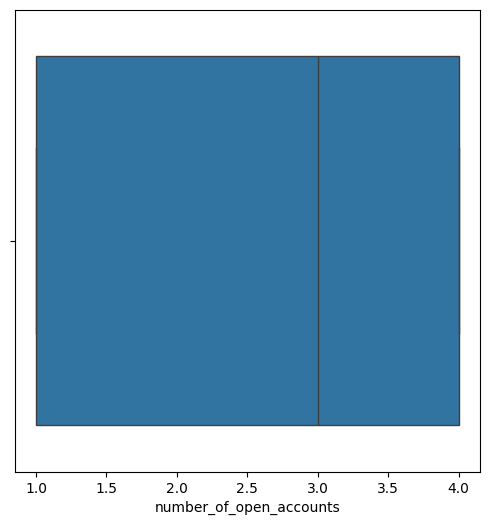

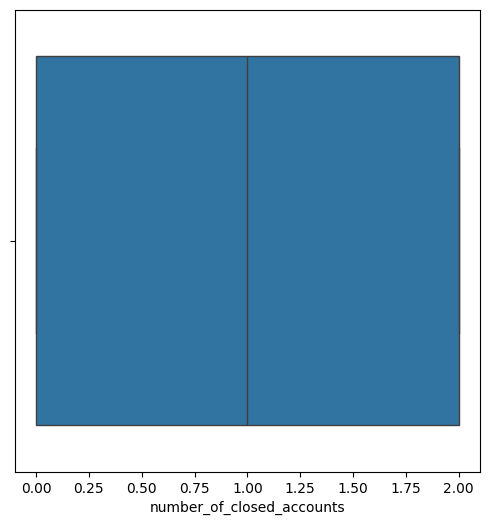

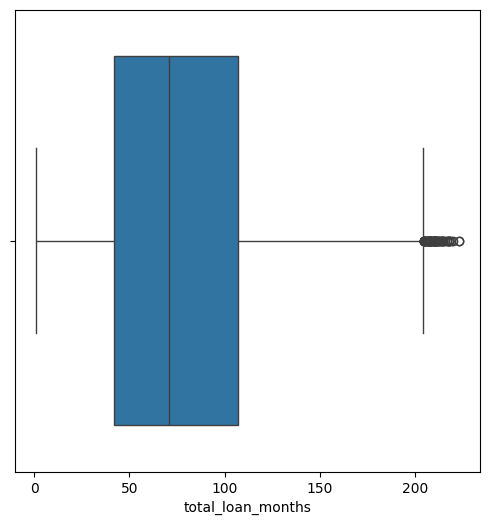

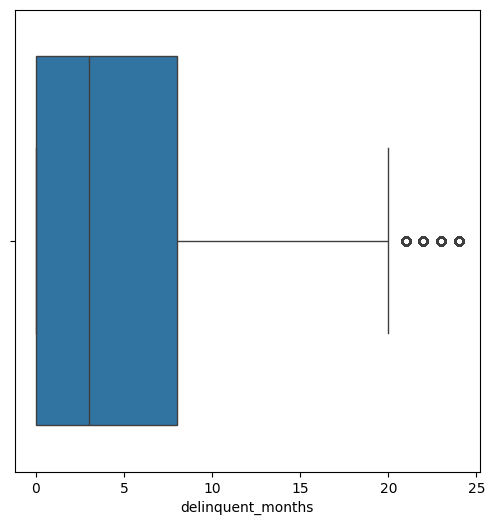

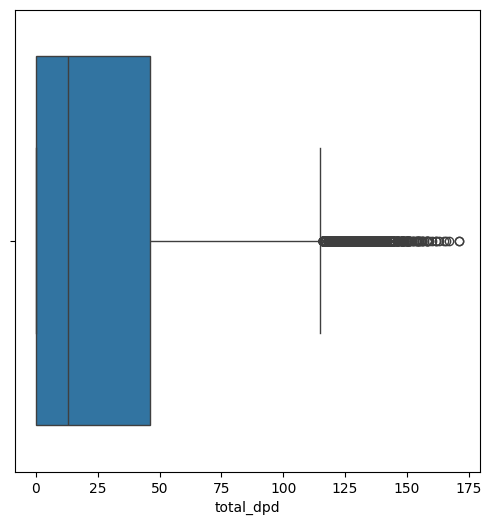

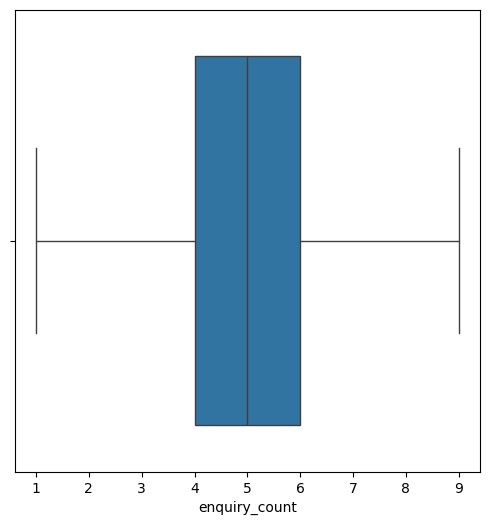

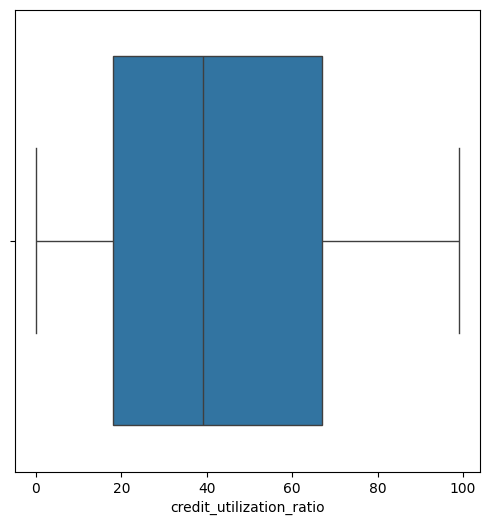

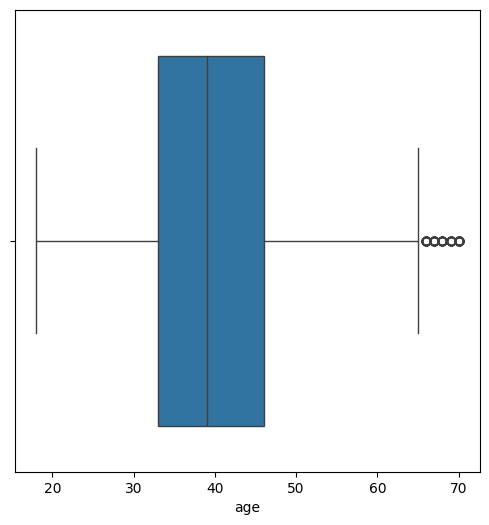

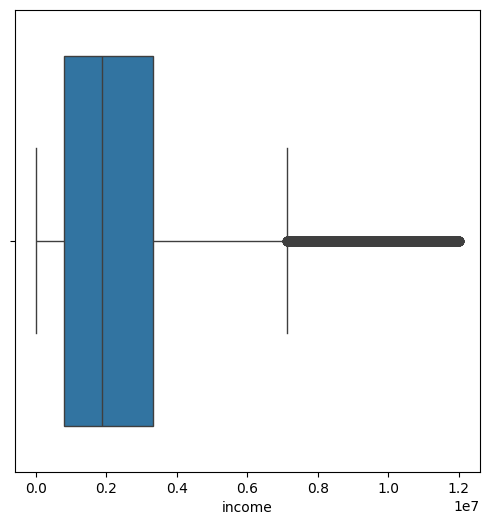

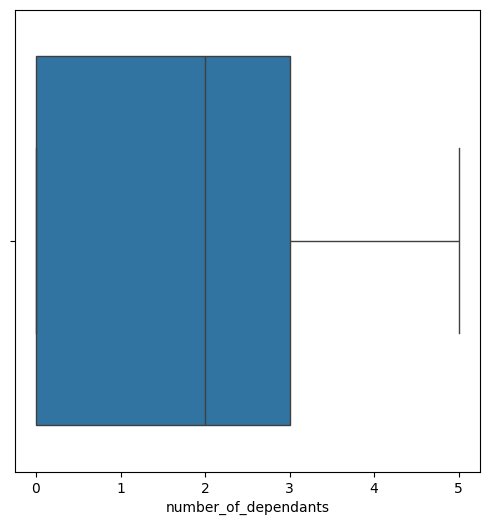

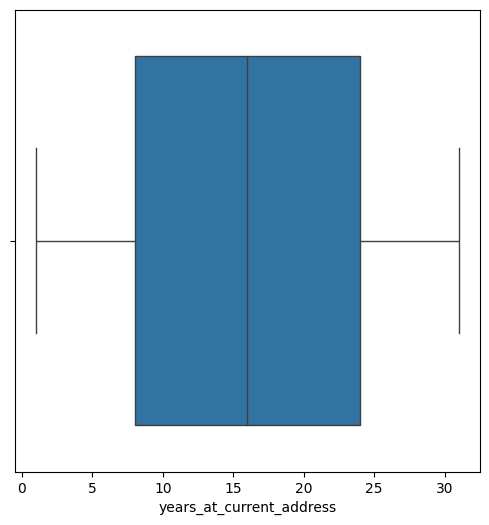

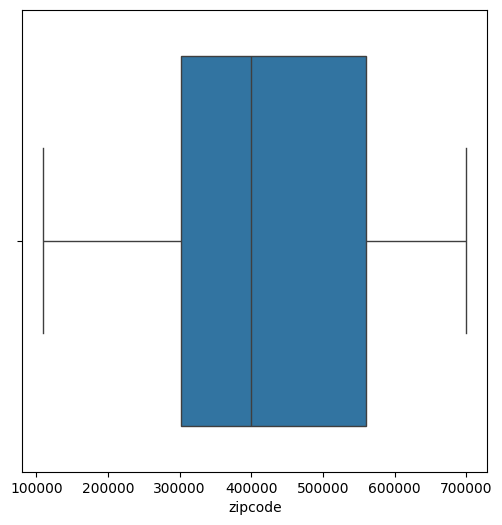

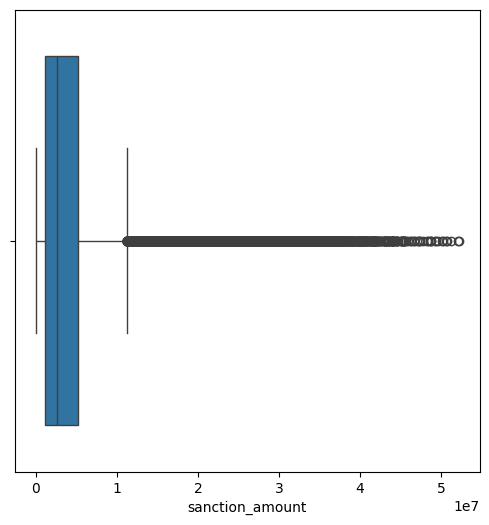

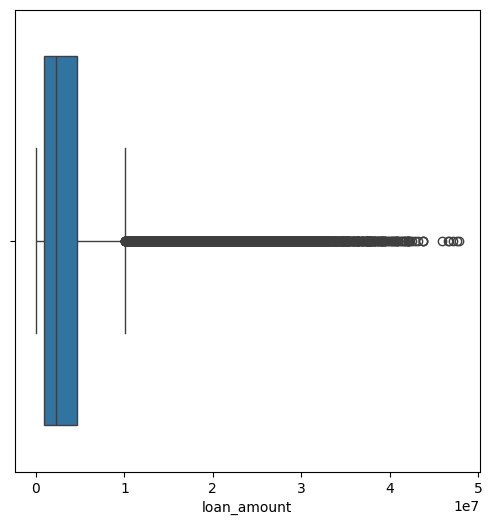

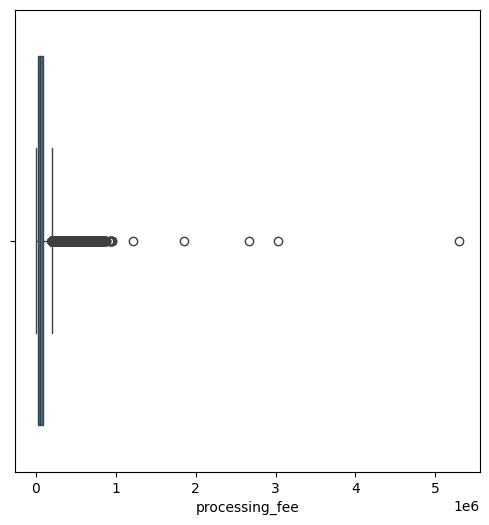

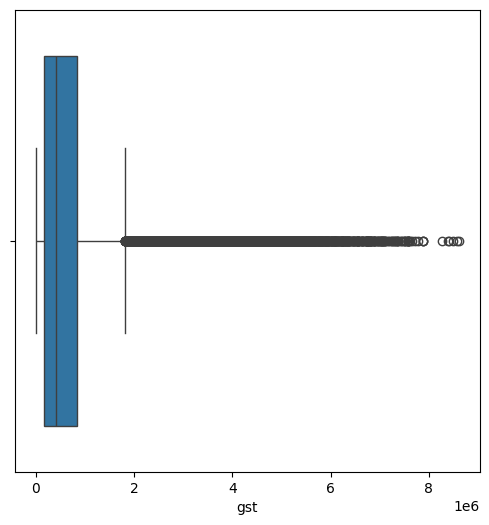

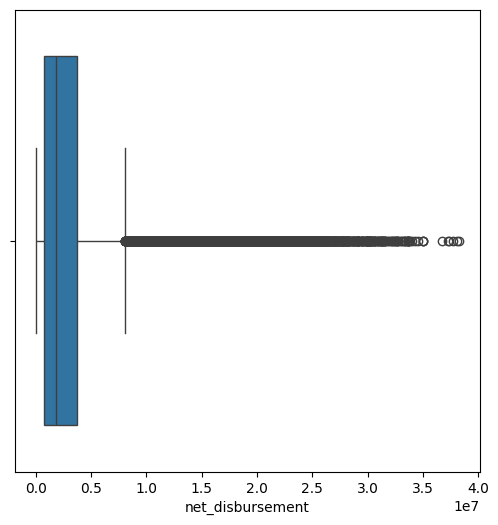

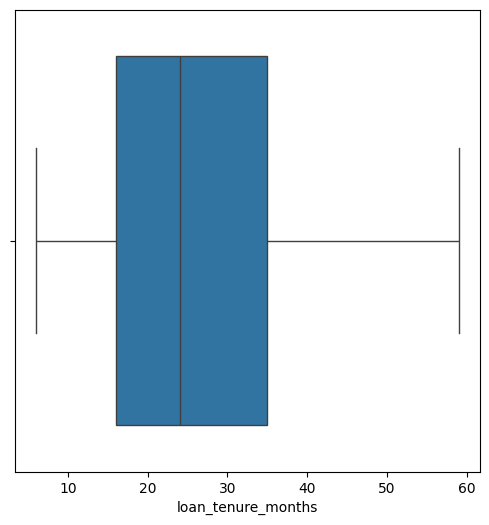

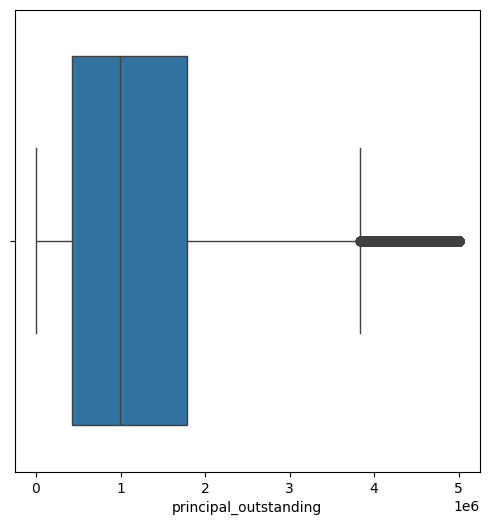

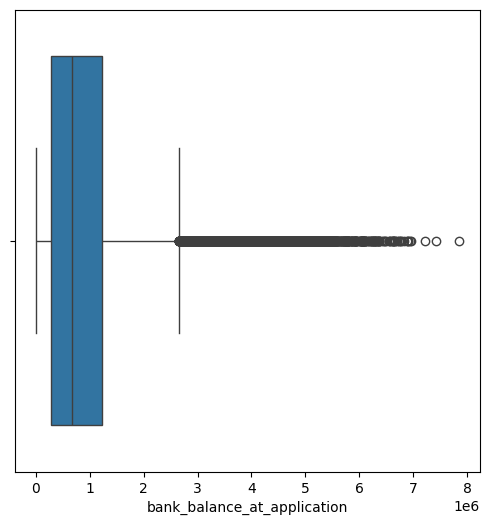

In [40]:
for cols in visualize_df:
    plt.figure(figsize=(6,6))
    sns.boxplot(x=df_train[cols])

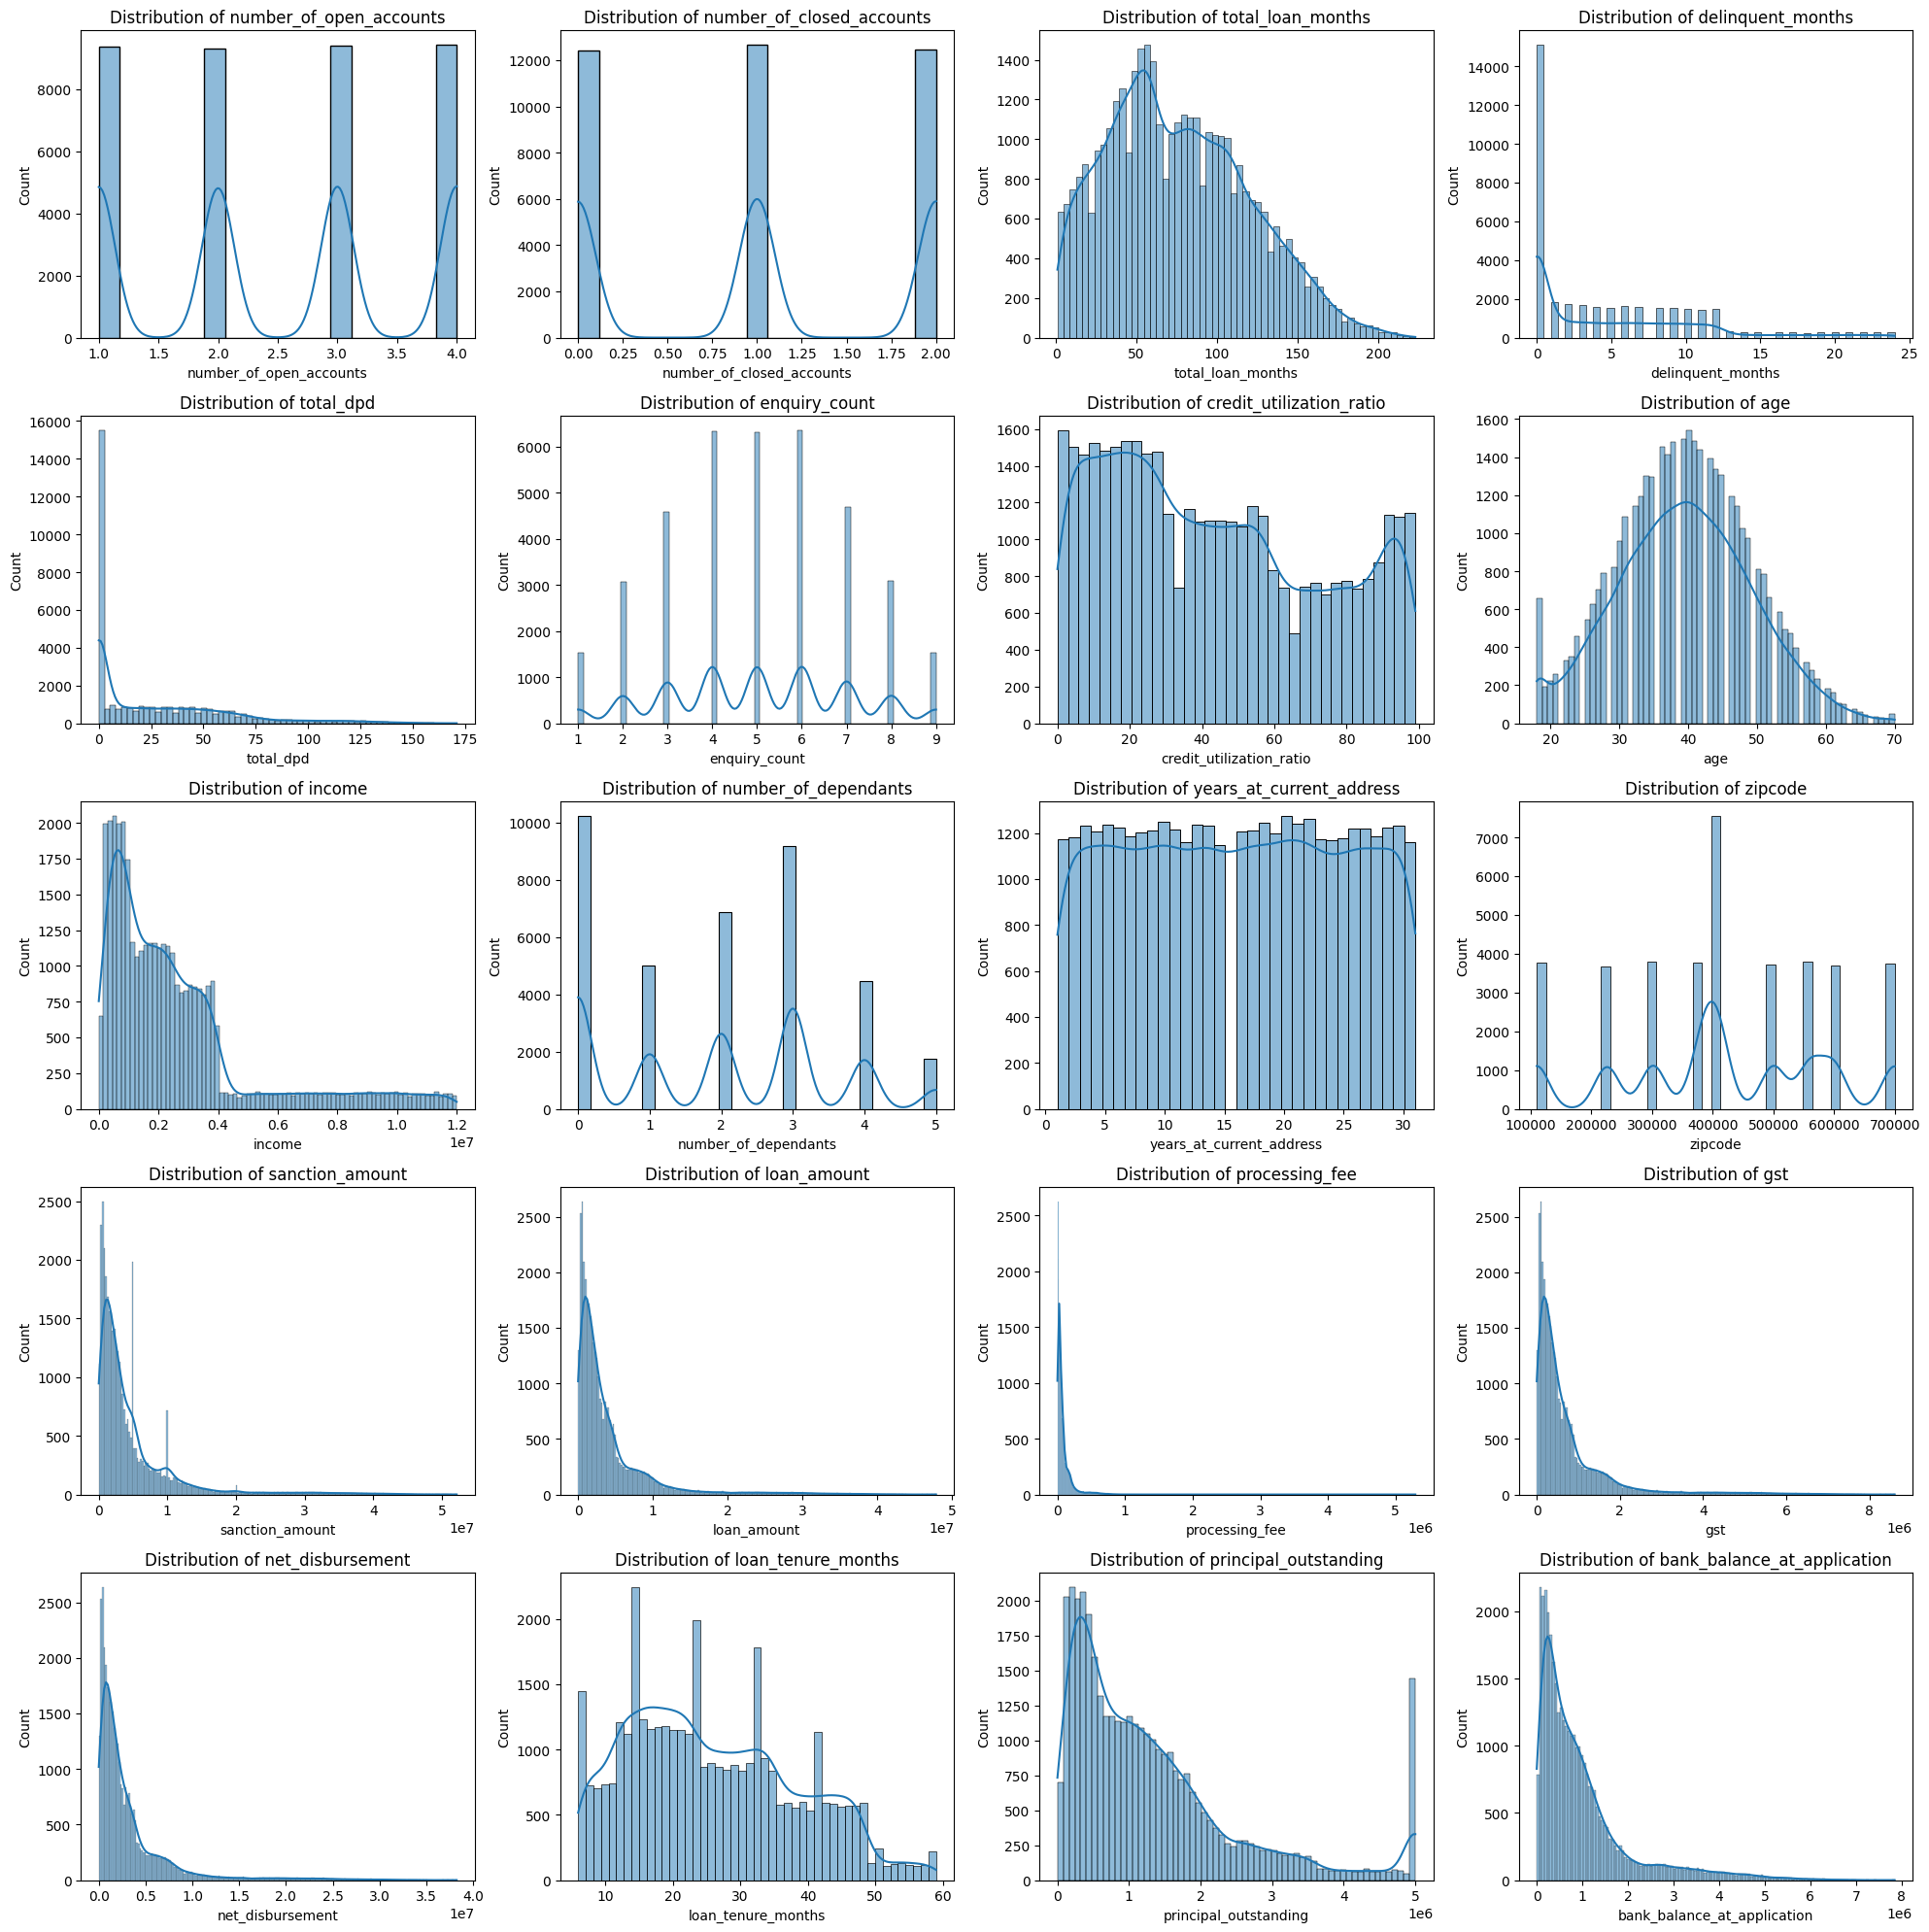

In [41]:
import math

num_cols = 4
num_plots = len(visualize_df)
num_rows = math.ceil(num_plots / num_cols)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 4 * num_rows))
axes = axes.flatten()

for i, col in enumerate(visualize_df):
    sns.histplot(x=df_train[col], ax=axes[i], kde=True)
    axes[i].set_title(f"Distribution of {col}")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### processing fee is heavely skewed

In [42]:
df_train.processing_fee.describe()

count    3.750000e+04
mean     8.029068e+04
std      1.131281e+05
min      0.000000e+00
25%      1.922000e+04
50%      4.460000e+04
75%      9.242000e+04
max      5.293544e+06
Name: processing_fee, dtype: float64

In [56]:
df_train[df_train.processing_fee==df_train.processing_fee.max()][['loan_amount','processing_fee']]

,loan_amount,processing_fee
9898,3626000,5293543.52


In [57]:
df_train[(df_train.processing_fee/df_train.loan_amount)>0.03][['loan_amount','processing_fee']]

,loan_amount,processing_fee
23981,2234000,2669791.02
28174,966000,1214492.67
47089,1738000,1858964.77
29305,2616000,3036378.01
9898,3626000,5293543.52


### usually processing fees is 2 to 3 percent of the loan ammount and we only get 5 record so we will ignore them

In [59]:
df_train_1=df_train[(df_train.processing_fee/df_train.loan_amount)<0.03].copy()
df_train_1=df_train_1[(df_train_1.processing_fee/df_train_1.loan_amount)<0.03]

C:\Users\ayush\AppData\Local\Temp\ipykernel_29532\3085460778.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_train_1=df_train_1[(df_train.processing_fee/df_train.loan_amount)<0.03]


In [61]:
df_test=df_test[(df_test.processing_fee/df_test.loan_amount)<0.03].copy()

In [62]:
df_test.shape

(12497, 32)

In [65]:
categorical_colm = df.select_dtypes(exclude=['number']).columns.tolist()

In [66]:
categorical_colm

['cust_id',
 'gender',
 'marital_status',
 'employment_status',
 'residence_type',
 'city',
 'state',
 'loan_id',
 'loan_purpose',
 'loan_type',
 'disbursal_date',
 'installment_start_dt']

In [70]:
for cols in categorical_colm:
    print(cols,"-->",df_train_1[cols].unique())

cust_id --> ['C12747' 'C32496' 'C43676' ... 'C45237' 'C49229' 'C37785']
gender --> ['M' 'F']
marital_status --> ['Married' 'Single']
employment_status --> ['Self-Employed' 'Salaried']
residence_type --> ['Owned' 'Mortgage' 'Rented' nan]
city --> ['Hyderabad' 'Mumbai' 'Chennai' 'Bangalore' 'Pune' 'Kolkata' 'Ahmedabad'
 'Delhi' 'Lucknow' 'Jaipur']
state --> ['Telangana' 'Maharashtra' 'Tamil Nadu' 'Karnataka' 'West Bengal'
 'Gujarat' 'Delhi' 'Uttar Pradesh' 'Rajasthan']
loan_id --> ['L12747' 'L32496' 'L43676' ... 'L45237' 'L49229' 'L37785']
loan_purpose --> ['Home' 'Education' 'Personal' 'Auto' 'Personaal']
loan_type --> ['Secured' 'Unsecured']
disbursal_date --> ['2020-10-31' '2022-10-22' '2023-12-04' ... '2022-02-07' '2019-10-30'
 '2022-10-04']
installment_start_dt --> ['2020-11-11' '2022-10-27' '2023-12-29' ... '2024-08-19' '2019-07-28'
 '2019-07-25']


In [71]:
df_train_1['loan_purpose']=df_train_1['loan_purpose'].replace('Personaal','Personal')
df_train_1.loan_purpose.unique()

array(['Home', 'Education', 'Personal', 'Auto'], dtype=object)